# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 9**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 9.6 K-Nearest Neighbours – Exercises
## Exercise 1 – Recognise handwritten digits with KNN
Uses scikit-learn's built-in **Digits** dataset (1 797 images, 8 × 8 pixels, classes 0-9).

Images: (1797, 64) | classes: [0 1 2 3 4 5 6 7 8 9]


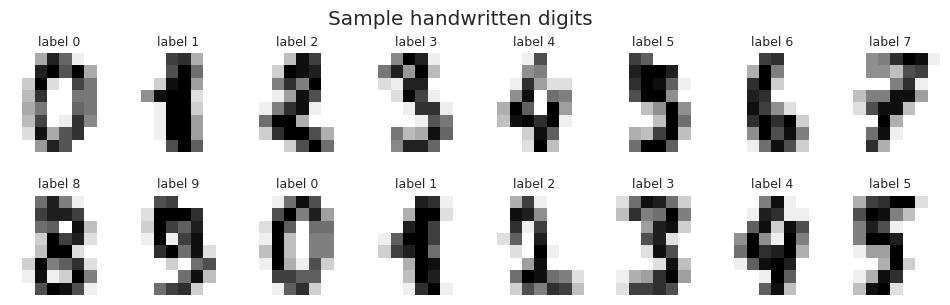

In [33]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print("Images:", X.shape, "| classes:", np.unique(y))

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, img, lab in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(f"label {lab}", fontsize=9); ax.axis("off")
plt.suptitle("Sample handwritten digits"); plt.show()

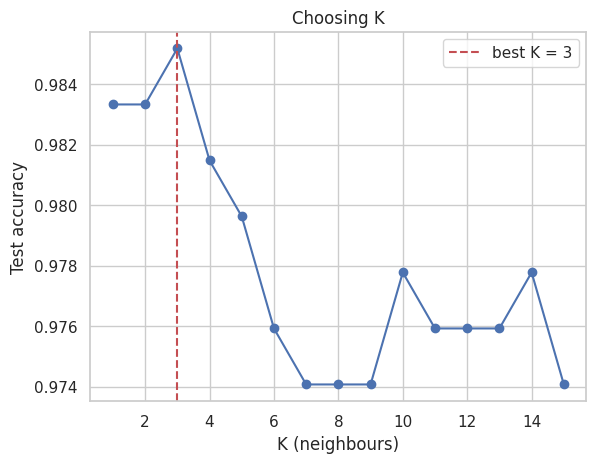

Accuracy per K: [0.9833, 0.9833, 0.9852, 0.9815, 0.9796, 0.9759, 0.9741, 0.9741, 0.9741, 0.9778, 0.9759, 0.9759, 0.9759, 0.9778, 0.9741]


In [34]:
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

# Choose K by comparing accuracy for K = 1..15
ks = range(1, 16)
acc = [KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).score(X_test, y_test) for k in ks]
best_k = ks[int(np.argmax(acc))]

plt.plot(ks, acc, "o-"); plt.axvline(best_k, color="r", ls="--", label=f"best K = {best_k}")
plt.xlabel("K (neighbours)"); plt.ylabel("Test accuracy"); plt.title("Choosing K"); plt.legend(); plt.show()
print("Accuracy per K:", [round(a, 4) for a in acc])

KNN (K=3) accuracy: 0.9852

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       1.00      1.00      1.00        53
           3       0.95      0.98      0.96        55
           4       1.00      0.96      0.98        54
           5       1.00      1.00      1.00        55
           6       1.00      1.00      1.00        54
           7       0.98      1.00      0.99        54
           8       1.00      0.94      0.97        52
           9       0.98      0.96      0.97        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540



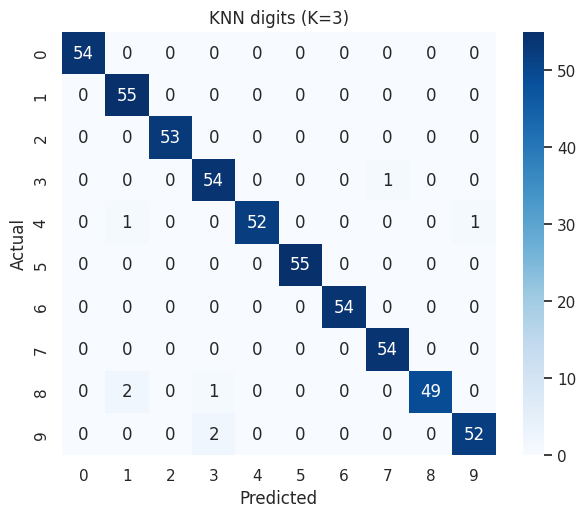

In [35]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2).fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"KNN (K={best_k}) accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}\n")
print(metrics.classification_report(y_test, y_pred))

plt.figure(figsize=(7, 5.5))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"KNN digits (K={best_k})"); plt.show()

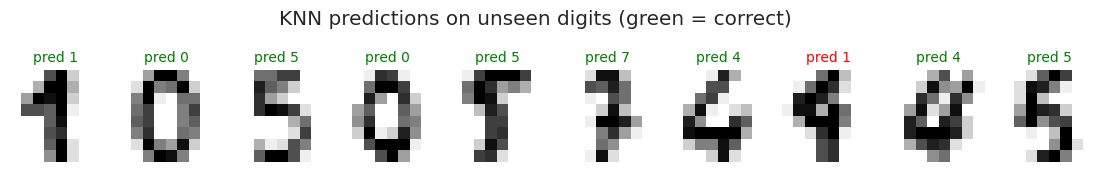

In [36]:
# Identify some new digits by appearance similarity to the samples
idx = np.random.default_rng(1).choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
for ax, i in zip(axes, idx):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r"); ax.axis("off")
    pred = knn.predict(X_test[i:i+1])[0]
    ax.set_title(f"pred {pred}", color="green" if pred == y_test[i] else "red", fontsize=10)
plt.suptitle("KNN predictions on unseen digits (green = correct)"); plt.show()

## Exercise 2 – Euclidean distance between a new entry and the existing data
Distance formula: $d = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$.
The new entry is not specified in the table, so the classic example **Brightness = 20, Saturation = 35** is used (change `new_entry` to try others).

In [37]:
colours = pd.DataFrame({
    "Brightness": [40, 50, 60, 10, 70, 60, 25],
    "Saturation": [20, 50, 90, 25, 70, 10, 80],
    "Class":      ["Red", "Blue", "Blue", "Red", "Blue", "Red", "Blue"],
})
new_entry = (20, 35)          # (Brightness, Saturation)

colours["Distance"] = np.sqrt((colours["Brightness"] - new_entry[0])**2 + (colours["Saturation"] - new_entry[1])**2)
ranked = colours.sort_values("Distance").reset_index(drop=True)
ranked.index += 1
ranked.rename_axis("Rank").round(2)

,Brightness,Saturation,Class,Distance
Rank,,,,
1,10,25,Red,14.14
2,40,20,Red,25.00
3,50,50,Blue,33.54
4,25,80,Blue,45.28
5,60,10,Red,47.17
6,70,70,Blue,61.03
7,60,90,Blue,68.01


5 nearest neighbours of (20, 35):
   Brightness  Saturation Class  Distance
1          10          25   Red     14.14
2          40          20   Red     25.00
3          50          50  Blue     33.54
4          25          80  Blue     45.28
5          60          10   Red     47.17

Votes: {'Red': 3, 'Blue': 2}
==> Predicted class for the new entry: Red
scikit-learn KNN prediction        : Red


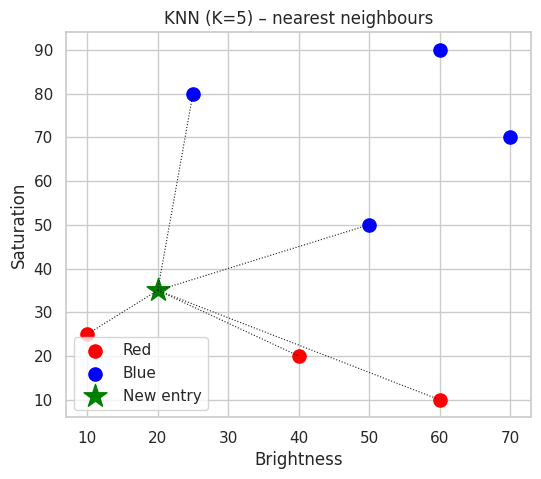

In [38]:
K = 5
top_k = ranked.head(K)
votes = top_k["Class"].value_counts()
print(f"{K} nearest neighbours of {new_entry}:")
print(top_k[["Brightness", "Saturation", "Class", "Distance"]].round(2).to_string())
print("\nVotes:", votes.to_dict())
print(f"==> Predicted class for the new entry: {votes.idxmax()}")

# Cross-check with scikit-learn
from sklearn.neighbors import KNeighborsClassifier
sk = KNeighborsClassifier(n_neighbors=K).fit(colours[["Brightness", "Saturation"]].values, colours["Class"])
print("scikit-learn KNN prediction        :", sk.predict([new_entry])[0])

plt.figure(figsize=(6, 5))
for c, col in [("Red", "red"), ("Blue", "blue")]:
    s = colours[colours.Class == c]; plt.scatter(s.Brightness, s.Saturation, c=col, s=90, label=c)
plt.scatter(*new_entry, c="green", marker="*", s=300, label="New entry")
for _, r in top_k.iterrows():
    plt.plot([new_entry[0], r.Brightness], [new_entry[1], r.Saturation], "k:", lw=0.8)
plt.xlabel("Brightness"); plt.ylabel("Saturation"); plt.title(f"KNN (K={K}) – nearest neighbours"); plt.legend(); plt.show()